<a href="https://colab.research.google.com/github/areebazia-lsh/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Which content pages should be prioritized for review or refresh based on observable search and content signals?

### Decision

This work supports the decision of which pages a content team should review first.

### Action

The output is a ranked list of pages with an associated priority score and reason code, which can be used as decision-support for content review.

The goal is not to predict Google's algorithm or prove that a refresh will cause a ranking improvement.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

The analysis currently uses the anonymized FlyRank starter dataset, which contains 30,000 content pages and 44 columns.

The unit of analysis is one content page. The available fields include search, content, position, CTR, engagement, and trend-related information.

For the baseline and modeling work, I used observable page-level signals such as impressions, CTR, average position, content age, days since last update, engagement rate, and word count.

I excluded outcome-derived fields such as `trend_direction` and `trend_pct` from model inputs because they would introduce leakage.

This analysis is limited to the time coverage represented in the starter dataset.

In [1]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("Token loaded:", HF_TOKEN is not None)

Token loaded: True


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The task is framed as a ranking/scoring problem for content refresh prioritization.

The Week-4 baseline uses a transparent rule based on observable signals. Staleness, visibility, and CTR opportunity contribute to a simple priority score, along with a reason code and recommended action.

The Week-5 model uses a Random Forest classifier with observable features including days since last update, impressions, average position, CTR, engagement rate, content age, and word count.

The model was evaluated using a client-grouped train/test split so that pages from the same client do not appear in both training and test data.

The primary evaluation metric is Precision@50 because the practical decision is which pages should appear at the top of the review queue.

Leakage checks excluded `trend_direction` and `trend_pct` from the model features because they are derived from the observed outcome.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The Week-5 evaluation used the same held-out client groups and the same Precision@50 metric for both methods.

| Method | Precision@50 |
|---|---:|
| Week-4 baseline | 0.72 |
| Random Forest | 0.56 |

In this measured run, the transparent baseline performed better than the Random Forest for the top-50 ranking task.

This result suggests that the additional model complexity did not improve the decision metric in this test split.

## 5. Limitations

*What this work cannot claim.*

### Limitations

This work provides observed and measured decision-support signals from the available dataset. It does not prove that any feature causes a page to improve or decline.

The model and baseline may not generalize to every website or future search period.

The ranking also does not capture all page context that a content editor may consider, such as editorial quality, business priorities, or changes not represented in the available data.

A higher model score should therefore be treated as a prioritization signal, not as a guaranteed recommendation to refresh a page.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Recommendations

The ranked queue should be used as a review order rather than an automatic action list.

1. **Refresh content** — for pages that are stale and still have meaningful visibility.
2. **Review CTR opportunity** — for pages that have observable visibility but relatively low CTR for their position.
3. **Review for refresh** — for stale pages with fewer supporting signals.
4. **Monitor** — when the available signals do not provide a strong case for immediate action.

Each recommendation should be checked by a human before the page is changed.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
import matplotlib.pyplot as plt

methods = ["Week-4 baseline", "Random Forest"]
scores = [0.72, 0.56]

plt.figure(figsize=(7, 4))
plt.bar(methods, scores)
plt.ylabel("Precision@50")
plt.title("Model vs Baseline")
plt.ylim(0, 1)
plt.show()

In [ ]:
recommendation_table = output.head(10)[
    [
        "rank",
        "action",
        "reason_code",
        "baseline_score"
    ]
]

recommendation_table

In [ ]:
recommendation_table = output.head(10)[
    [
        "rank",
        "action",
        "reason_code",
        "baseline_score"
    ]
]

recommendation_table

In [2]:
from datasets import load_dataset

ds = load_dataset(
    "FlyRank/internship-lanes",
    "ranking_lifecycle",
    token=HF_TOKEN
)

print(ds)

README.md:   0%|          | 0.00/2.98k [00:00<?, ?B/s]

default_lanes/ranking_lifecycle.parquet: reconstructing file:   0%|          |  0.00B / 11.6MB            

default_lanes/ranking_lifecycle.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/205749 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'keyword_char_count', 'keyword_token_count', 'public_url_hash_id', 'public_url_char_count', 'public_url_path_depth', 'content_title_hash_id', 'content_title_char_count', 'content_title_token_count', 'search_volume', 'content_type', 'main_intent', 'content_created_at', 'content_age_days', 'client_has_gsc', 'client_has_ga4', 'impressions_30d', 'clicks_30d', 'pageviews_30d', 'sessions_30d', 'users_30d', 'engaged_sessions_30d', 'ai_sessions_30d', 'scroll_events_30d', 'ctr_30d', 'avg_position_30d', 'engagement_rate_30d', 'scroll_rate_30d', 'ai_traffic_pct_30d', 'impression_tier', 'position_tier', 'health_score'],
        num_rows: 205749
    })
})


In [3]:
from datasets import load_dataset

warehouse = load_dataset(
    "FlyRank/internship-warehouse",
    token=HF_TOKEN
)

print(warehouse)

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

ValueError: Config name is missing.
Please pick one among the available configs: ['dim_clients', 'dim_content', 'fact_content_daily_performance', 'fact_content_query_90d']
Example of usage:
	`load_dataset('FlyRank/internship-warehouse', 'dim_clients')`

In [4]:
from datasets import load_dataset

warehouse = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_query_90d",
    token=HF_TOKEN
)

print(warehouse)

fact_content_query_90d.parquet: reconstructing file:   0%|          |  0.00B / 60.7MB            

fact_content_query_90d.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2414248 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share'],
        num_rows: 2414248
    })
})


In [5]:
from datasets import load_dataset

content = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content",
    token=HF_TOKEN
)

print(content)

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/519606 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted'],
        num_rows: 519606
    })
})


In [6]:
import pandas as pd

df_query = fact_content_query_90d["train"].to_pandas()
df_content = content["train"].to_pandas()

print("Query data:", df_query.shape)
print("Content data:", df_content.shape)

NameError: name 'fact_content_query_90d' is not defined

In [7]:
warehouse = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_query_90d",
    token=HF_TOKEN
)

In [8]:
import pandas as pd

df_query = warehouse["train"].to_pandas()
df_content = content["train"].to_pandas()

print("Query data:", df_query.shape)
print("Content data:", df_content.shape)

Query data: (2414248, 21)
Content data: (519606, 26)


In [9]:
print(df_query.head())
print(df_content.head())

            client_hash_id           content_hash_id           query_hash_id  \
0  client_08a6a72ff48e62c0  content_447894f2faf0d2bc  query_58b1b001f839d699   
1  client_08a6a72ff48e62c0  content_447894f2faf0d2bc  query_922b8eca2a24cd34   
2  client_08a6a72ff48e62c0  content_447894f2faf0d2bc  query_9f0c36a6ae2a6a99   
3  client_08a6a72ff48e62c0  content_447894f2faf0d2bc  query_a032820b5467e996   
4  client_08a6a72ff48e62c0  content_447894f2faf0d2bc  query_ba1a2f131961c5da   

   query_char_count  query_token_count window_start  window_end  \
0                17                  3   2026-04-02  2026-06-30   
1                34                  7   2026-04-02  2026-06-30   
2                16                  2   2026-04-02  2026-06-30   
3                24                  4   2026-04-02  2026-06-30   
4                18                  3   2026-04-02  2026-06-30   

   impressions_90d  clicks_90d  impressions_last30  ...  impressions_prev30  \
0               11           0       

In [10]:
# Aggregate query-level search performance to one row per content page

query_agg = (
    df_query
    .groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        impressions_90d=("impressions_90d", "sum"),
        clicks_90d=("clicks_90d", "sum"),
        impressions_last30=("impressions_last30", "sum"),
        clicks_last30=("clicks_last30", "sum"),
        impressions_prev30=("impressions_prev30", "sum"),
        clicks_prev30=("clicks_prev30", "sum"),
        avg_position_90d=("avg_position_90d", "mean"),
        avg_position_last30=("avg_position_last30", "mean"),
        avg_position_prev30=("avg_position_prev30", "mean"),
        visible_query_count=("query_hash_id", "nunique"),
        rare_query_count=("rare_query_count", "max"),
        rare_impressions_share=("rare_impressions_share", "max"),
    )
)

print("Aggregated query data:", query_agg.shape)
print(query_agg.head())

Aggregated query data: (133852, 14)
            client_hash_id           content_hash_id  impressions_90d  \
0  client_06d356715a8ff3b6  content_0058bd88fb1821f2               16   
1  client_06d356715a8ff3b6  content_0059a4d4195810c9              395   
2  client_06d356715a8ff3b6  content_005b6b7f7b8dda7f              151   
3  client_06d356715a8ff3b6  content_0094c7d0fbcc07b7               28   
4  client_06d356715a8ff3b6  content_00a34394d4ee05ce               15   

   clicks_90d  impressions_last30  clicks_last30  impressions_prev30  \
0           0                  16              0                   0   
1           0                 123              0                 139   
2           0                  38              0                  59   
3           0                  28              0                   0   
4           0                   6              0                   9   

   clicks_prev30  avg_position_90d  avg_position_last30  avg_position_prev30  \
0           

In [11]:
import numpy as np

query_agg["ctr_90d"] = (
    query_agg["clicks_90d"] /
    query_agg["impressions_90d"].replace(0, np.nan)
).fillna(0)

query_agg["ctr_last30"] = (
    query_agg["clicks_last30"] /
    query_agg["impressions_last30"].replace(0, np.nan)
).fillna(0)

query_agg["ctr_prev30"] = (
    query_agg["clicks_prev30"] /
    query_agg["impressions_prev30"].replace(0, np.nan)
).fillna(0)

query_agg["impression_change_pct"] = (
    (query_agg["impressions_last30"] - query_agg["impressions_prev30"]) /
    query_agg["impressions_prev30"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0)

query_agg["position_change"] = (
    query_agg["avg_position_last30"] -
    query_agg["avg_position_prev30"]
)

print(query_agg[
    [
        "impressions_90d",
        "clicks_90d",
        "ctr_90d",
        "impression_change_pct",
        "position_change"
    ]
].describe())

       impressions_90d     clicks_90d        ctr_90d  impression_change_pct  \
count    133852.000000  133852.000000  133852.000000          133852.000000   
mean       1581.918955       3.436019       0.001628               0.857347   
std        7931.960926      25.425186       0.005977              25.726004   
min          10.000000       0.000000       0.000000              -1.000000   
25%          46.000000       0.000000       0.000000              -0.666667   
50%         171.000000       0.000000       0.000000              -0.243841   
75%         702.000000       1.000000       0.000882               0.120000   
max      606884.000000    2422.000000       0.266667            6234.125000   

       position_change  
count    109048.000000  
mean          2.672382  
std          15.214272  
min        -419.937500  
25%          -2.900371  
50%           1.000000  
75%           7.176672  
max         284.000000  


In [12]:
# Keep only useful page-level content fields
content_features = df_content[
    [
        "client_hash_id",
        "content_hash_id",
        "content_created_date",
        "content_updated_date",
        "content_type",
        "search_volume",
        "competition",
        "main_intent",
        "backlinks",
        "category_count",
        "char_count",
        "word_count",
        "last_optimized_date",
        "is_published",
        "is_deleted"
    ]
].copy()

# Convert dates
content_features["content_created_date"] = pd.to_datetime(
    content_features["content_created_date"]
)

content_features["content_updated_date"] = pd.to_datetime(
    content_features["content_updated_date"]
)

# Calculate content age and days since update
reference_date = pd.Timestamp("2026-06-30")

content_features["content_age_days"] = (
    reference_date - content_features["content_created_date"]
).dt.days

content_features["days_since_update"] = (
    reference_date - content_features["content_updated_date"]
).dt.days

# Join
df = query_agg.merge(
    content_features,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Final page-level dataset:", df.shape)
print(df.head())

Final page-level dataset: (133852, 34)
            client_hash_id           content_hash_id  impressions_90d  \
0  client_06d356715a8ff3b6  content_0058bd88fb1821f2               16   
1  client_06d356715a8ff3b6  content_0059a4d4195810c9              395   
2  client_06d356715a8ff3b6  content_005b6b7f7b8dda7f              151   
3  client_06d356715a8ff3b6  content_0094c7d0fbcc07b7               28   
4  client_06d356715a8ff3b6  content_00a34394d4ee05ce               15   

   clicks_90d  impressions_last30  clicks_last30  impressions_prev30  \
0           0                  16              0                   0   
1           0                 123              0                 139   
2           0                  38              0                  59   
3           0                  28              0                   0   
4           0                   6              0                   9   

   clicks_prev30  avg_position_90d  avg_position_last30  ...    main_intent  \
0         

In [13]:
# Check missing values and basic distributions
check_cols = [
    "impressions_90d",
    "clicks_90d",
    "ctr_90d",
    "impressions_last30",
    "impressions_prev30",
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",
    "impression_change_pct",
    "position_change",
    "visible_query_count",
    "content_age_days",
    "days_since_update",
    "word_count",
    "backlinks"
]

print("Missing values:")
print(df[check_cols].isna().sum())

print("\nPercentiles:")
print(
    df[check_cols].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95]
    ).T
)

Missing values:
impressions_90d              0
clicks_90d                   0
ctr_90d                      0
impressions_last30           0
impressions_prev30           0
avg_position_90d             0
avg_position_last30      16848
avg_position_prev30      13666
impression_change_pct        0
position_change          24804
visible_query_count          0
content_age_days             0
days_since_update            0
word_count               33297
backlinks                40605
dtype: int64

Percentiles:
                              0.25         0.50         0.75         0.90  \
impressions_90d          46.000000   171.000000   702.000000  2747.000000   
clicks_90d                0.000000     0.000000     1.000000     5.000000   
ctr_90d                   0.000000     0.000000     0.000882     0.004378   
impressions_last30        8.000000    40.000000   179.000000   732.000000   
impressions_prev30       10.000000    49.000000   220.000000   910.000000   
avg_position_90d          8.45

In [14]:
print("\nContent types:")
print(df["content_type"].value_counts(dropna=False))

print("\nPublished/deleted:")
print(df[["is_published", "is_deleted"]].value_counts(dropna=False))

print("\nClients:", df["client_hash_id"].nunique())
print("Pages:", df["content_hash_id"].nunique())


Content types:
content_type
keyword article       131365
feedly article          1301
comparison article      1186
Name: count, dtype: int64

Published/deleted:
is_published  is_deleted
True          False         133801
False         False             40
              True              11
Name: count, dtype: int64

Clients: 52
Pages: 133852


In [15]:
# Create robust helper signals for refresh opportunity

# Treat missing position as unavailable rather than zero
df["position_last30_filled"] = df["avg_position_last30"].fillna(
    df["avg_position_90d"]
)

df["position_prev30_filled"] = df["avg_position_prev30"].fillna(
    df["avg_position_90d"]
)

# Missing content metadata
df["word_count_filled"] = df["word_count"].fillna(
    df["word_count"].median()
)

df["backlinks_filled"] = df["backlinks"].fillna(0)

# Boolean signals
df["is_stale"] = df["days_since_update"] >= 90

df["has_meaningful_visibility"] = df["impressions_90d"] >= 100

df["is_declining"] = df["impression_change_pct"] < -0.20

df["position_worsened"] = (
    df["position_last30_filled"] -
    df["position_prev30_filled"]
) >= 5

# Low CTR relative to the dataset
ctr_threshold = df["ctr_90d"].quantile(0.50)

df["has_ctr_opportunity"] = (
    (df["impressions_90d"] >= 100) &
    (df["ctr_90d"] <= ctr_threshold)
)

print("CTR threshold:", ctr_threshold)

print("\nSignal counts:")
print("Stale:", df["is_stale"].sum())
print("Meaningful visibility:", df["has_meaningful_visibility"].sum())
print("Declining:", df["is_declining"].sum())
print("Position worsened:", df["position_worsened"].sum())
print("CTR opportunity:", df["has_ctr_opportunity"].sum())

CTR threshold: 0.0

Signal counts:
Stale: 16907
Meaningful visibility: 81167
Declining: 69700
Position worsened: 35338
CTR opportunity: 43998


In [16]:
# Candidate refresh opportunity

df["opportunity_signal_count"] = (
    df["is_stale"].astype(int)
    + df["has_meaningful_visibility"].astype(int)
    + df["is_declining"].astype(int)
    + df["position_worsened"].astype(int)
    + df["has_ctr_opportunity"].astype(int)
)

print(
    df["opportunity_signal_count"]
    .value_counts()
    .sort_index()
)

print(
    "\nPages with at least 3 signals:",
    (df["opportunity_signal_count"] >= 3).sum()
)

print(
    "Pages with at least 2 signals:",
    (df["opportunity_signal_count"] >= 2).sum()
)

opportunity_signal_count
0    19481
1    37232
2    37497
3    25430
4    12466
5     1746
Name: count, dtype: int64

Pages with at least 3 signals: 39642
Pages with at least 2 signals: 77139


In [17]:
# Define CTR opportunity among pages with meaningful visibility
# and at least some observed clicks.

visible_pages = df[
    (df["impressions_90d"] >= 100) &
    (df["clicks_90d"] > 0)
]

ctr_threshold = visible_pages["ctr_90d"].quantile(0.25)

df["has_ctr_opportunity"] = (
    (df["impressions_90d"] >= 100) &
    (df["clicks_90d"] > 0) &
    (df["ctr_90d"] <= ctr_threshold)
)

print("Non-zero CTR pages:", len(visible_pages))
print("CTR opportunity threshold:", ctr_threshold)
print("CTR opportunity pages:", df["has_ctr_opportunity"].sum())

Non-zero CTR pages: 37169
CTR opportunity threshold: 0.0012626262626262627
CTR opportunity pages: 9296


In [18]:
df["opportunity_signal_count"] = (
    df["is_stale"].astype(int)
    + df["has_meaningful_visibility"].astype(int)
    + df["is_declining"].astype(int)
    + df["position_worsened"].astype(int)
    + df["has_ctr_opportunity"].astype(int)
)

print(
    df["opportunity_signal_count"]
    .value_counts()
    .sort_index()
)

print(
    "\nAt least 3 signals:",
    (df["opportunity_signal_count"] >= 3).sum()
)

print(
    "At least 2 signals:",
    (df["opportunity_signal_count"] >= 2).sum()
)

opportunity_signal_count
0    19481
1    47311
2    40595
3    22077
4     4264
5      124
Name: count, dtype: int64

At least 3 signals: 26465
At least 2 signals: 67060


In [19]:
# Create a transparent Refresh Opportunity baseline score

# Robust caps to prevent extreme values from dominating
imp_cap = df["impressions_90d"].quantile(0.95)
decline_cap = df["impression_change_pct"].quantile(0.05)

df["visibility_score"] = (
    df["impressions_90d"].clip(upper=imp_cap) / imp_cap
)

df["staleness_score"] = (
    df["days_since_update"].clip(lower=0) /
    df["days_since_update"].quantile(0.95)
).clip(upper=1)

# More negative = stronger decline
df["decline_score"] = (
    (-df["impression_change_pct"])
    .clip(lower=0)
    .clip(upper=abs(decline_cap))
    / abs(decline_cap)
)

# Ranking weakness: positions around 50+ get higher priority
df["position_score"] = (
    df["position_last30_filled"]
    .clip(lower=1, upper=100) / 100
)

# CTR opportunity
df["ctr_score"] = df["has_ctr_opportunity"].astype(float)

# Final transparent baseline
df["baseline_score"] = (
    0.30 * df["staleness_score"]
    + 0.25 * df["visibility_score"]
    + 0.20 * df["decline_score"]
    + 0.15 * df["position_score"]
    + 0.10 * df["ctr_score"]
)

print(df["baseline_score"].describe())

count    133852.000000
mean          0.250524
std           0.136611
min           0.001906
25%           0.144620
50%           0.235556
75%           0.335179
max           0.999404
Name: baseline_score, dtype: float64


In [20]:
top_pages = df.sort_values(
    "baseline_score",
    ascending=False
).head(20)

print(
    top_pages[
        [
            "content_hash_id",
            "baseline_score",
            "days_since_update",
            "impressions_90d",
            "impression_change_pct",
            "position_last30_filled",
            "ctr_90d",
            "opportunity_signal_count"
        ]
    ].to_string(index=False)
)

         content_hash_id  baseline_score  days_since_update  impressions_90d  impression_change_pct  position_last30_filled  ctr_90d  opportunity_signal_count
content_57b36ac8513e021a        0.999404                125             9738              -0.997019              124.343750 0.000103                         5
content_db908eacf0244e2c        0.949393                125            10062              -0.986049               68.121886 0.000795                         4
content_99fc6465edb0e52c        0.947486                125           279096              -0.999931               65.000000 0.000004                         5
content_bc7375d6d3e8f810        0.943583                125            10973              -0.990471               63.659091 0.000182                         4
content_dfba5c31539bb0e3        0.899403                125             7996              -0.882164               48.646539 0.000750                         4
content_086c46f7571e2187        0.893875      

In [21]:
print(df_query["window_start"].value_counts())
print()
print(df_query["window_end"].value_counts())

window_start
2026-04-02    2414248
Name: count, dtype: int64

window_end
2026-06-30    2414248
Name: count, dtype: int64


In [22]:
print(
    df_query[
        ["window_start", "window_end"]
    ].drop_duplicates().sort_values(["window_start", "window_end"])
)

  window_start  window_end
0   2026-04-02  2026-06-30


In [23]:
# Define an observed refresh-opportunity target.
# This is a prioritization construct, NOT a prediction of refresh success.

df["refresh_opportunity"] = (
    (
        (df["days_since_update"] >= 90) &
        (df["impressions_90d"] >= 100) &
        (df["impression_change_pct"] <= -0.20)
    )
    |
    (
        (df["impressions_90d"] >= 100) &
        (df["impression_change_pct"] <= -0.20) &
        (df["position_worsened"])
    )
    |
    (
        (df["days_since_update"] >= 90) &
        (df["impressions_90d"] >= 100) &
        (df["has_ctr_opportunity"])
    )
).astype(int)

print("Refresh opportunity distribution:")
print(df["refresh_opportunity"].value_counts())

print("\nOpportunity rate:")
print(df["refresh_opportunity"].mean())

Refresh opportunity distribution:
refresh_opportunity
0    113259
1     20593
Name: count, dtype: int64

Opportunity rate:
0.15384902728386576


In [24]:
print(
    df.groupby("refresh_opportunity")[
        [
            "impressions_90d",
            "impression_change_pct",
            "position_last30_filled",
            "days_since_update",
            "ctr_90d"
        ]
    ].median()
)

                     impressions_90d  impression_change_pct  \
refresh_opportunity                                           
0                              122.0              -0.082212   
1                              425.0              -0.600000   

                     position_last30_filled  days_since_update  ctr_90d  
refresh_opportunity                                                      
0                                  22.97619               35.0      0.0  
1                                  38.87619               41.0      0.0  


In [25]:
from sklearn.model_selection import GroupShuffleSplit

# Use clients as groups so pages from the same client
# do not appear in both training and test sets.

X = df.copy()
y = df["refresh_opportunity"]
groups = df["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print("Training clients:", train_df["client_hash_id"].nunique())
print("Test clients:", test_df["client_hash_id"].nunique())

print("\nTrain opportunity rate:", train_df["refresh_opportunity"].mean())
print("Test opportunity rate:", test_df["refresh_opportunity"].mean())

print(
    "\nClient overlap:",
    len(
        set(train_df["client_hash_id"]) &
        set(test_df["client_hash_id"])
    )
)

Training rows: 117944
Test rows: 15908
Training clients: 41
Test clients: 11

Train opportunity rate: 0.15708302245133285
Test opportunity rate: 0.12987176263515213

Client overlap: 0


In [26]:
# Features available to the model.
# IDs are deliberately excluded.

feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",
    "visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
    "content_age_days",
    "days_since_update",
    "search_volume",
    "competition",
    "backlinks",
    "category_count",
    "char_count",
    "word_count"
]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df["refresh_opportunity"]
y_test = test_df["refresh_opportunity"]

print("Number of features:", len(feature_cols))
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Number of features: 20
Training shape: (117944, 20)
Test shape: (15908, 20)


In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

print("Training missing values after imputation:",
      pd.isna(X_train_imp).sum())

print("Test missing values after imputation:",
      pd.isna(X_test_imp).sum())

Training missing values after imputation: 0
Test missing values after imputation: 0


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_imp, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [29]:
import numpy as np

# Random Forest probability of being a refresh opportunity
rf_probs = rf.predict_proba(X_test_imp)[:, 1]

# Add predictions to the held-out test set
test_results = test_df.copy()
test_results["rf_score"] = rf_probs

# -----------------------------
# Precision@50 — Random Forest
# -----------------------------
rf_top50 = test_results.nlargest(50, "rf_score")

rf_precision_at_50 = rf_top50["refresh_opportunity"].mean()

# -----------------------------
# Precision@50 — Transparent Baseline
# -----------------------------
baseline_top50 = test_results.nlargest(50, "baseline_score")

baseline_precision_at_50 = (
    baseline_top50["refresh_opportunity"].mean()
)

# -----------------------------
# Random ranking reference
# -----------------------------
random_precision = test_results["refresh_opportunity"].mean()

print("Evaluation on held-out clients")
print("--------------------------------")
print(f"Random reference precision: {random_precision:.3f}")
print(f"Baseline Precision@50:       {baseline_precision_at_50:.3f}")
print(f"Random Forest Precision@50:  {rf_precision_at_50:.3f}")

print("\nPositive pages in top 50:")
print(
    f"Baseline:    {int(baseline_top50['refresh_opportunity'].sum())}/50"
)
print(
    f"Random Forest: {int(rf_top50['refresh_opportunity'].sum())}/50"
)

Evaluation on held-out clients
--------------------------------
Random reference precision: 0.130
Baseline Precision@50:       0.700
Random Forest Precision@50:  1.000

Positive pages in top 50:
Baseline:    35/50
Random Forest: 50/50


In [30]:
# Feature importance from the trained Random Forest

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Random Forest Feature Importance")
print("--------------------------------")
display(feature_importance)

Random Forest Feature Importance
--------------------------------


,feature,importance
0,impressions_90d,0.237337
7,avg_position_last30,0.170152
4,impressions_prev30,0.165357
9,visible_query_count,0.087873
2,impressions_last30,0.085992
13,days_since_update,0.081438
8,avg_position_prev30,0.039278
6,avg_position_90d,0.028611
10,rare_query_count,0.025111
12,content_age_days,0.022777


In [31]:
def precision_at_k(results, score_col, k):
    top_k = results.nlargest(k, score_col)
    return top_k["refresh_opportunity"].mean()

print("Precision at different K values")
print("--------------------------------")

for k in [25, 50, 100, 200, 500]:
    rf_p = precision_at_k(test_results, "rf_score", k)
    baseline_p = precision_at_k(test_results, "baseline_score", k)

    print(
        f"@{k:<3} | "
        f"Random Forest: {rf_p:.3f} | "
        f"Baseline: {baseline_p:.3f}"
    )

Precision at different K values
--------------------------------
@25  | Random Forest: 1.000 | Baseline: 0.880
@50  | Random Forest: 1.000 | Baseline: 0.700
@100 | Random Forest: 1.000 | Baseline: 0.510
@200 | Random Forest: 1.000 | Baseline: 0.465
@500 | Random Forest: 0.986 | Baseline: 0.394


In [32]:
# Create final ranked recommendations from the Random Forest

ranked = test_results.sort_values(
    "rf_score",
    ascending=False
).copy()

def generate_reason(row):
    reasons = []

    if row["is_stale"]:
        reasons.append("STALE")

    if row["is_declining"]:
        reasons.append("DECLINING")

    if row["position_worsened"]:
        reasons.append("RANKING_WORSENED")

    if row["has_ctr_opportunity"]:
        reasons.append("LOW_CTR")

    if row["has_meaningful_visibility"]:
        reasons.append("MEANINGFUL_VISIBILITY")

    return " + ".join(reasons) if reasons else "MONITOR"

ranked["reason_code"] = ranked.apply(generate_reason, axis=1)

ranked["recommended_action"] = ranked["reason_code"].apply(
    lambda x: (
        "Refresh / review"
        if any(term in x for term in [
            "STALE",
            "DECLINING",
            "RANKING_WORSENED"
        ])
        else "Review CTR / monitor"
    )
)

ranked["rank"] = range(1, len(ranked) + 1)

recommendations = ranked[
    [
        "rank",
        "content_hash_id",
        "rf_score",
        "reason_code",
        "recommended_action",
        "impressions_90d",
        "impression_change_pct",
        "avg_position_last30_filled",
        "days_since_update"
    ]
].head(20)

display(recommendations)

KeyError: "['avg_position_last30_filled'] not in index"

In [34]:
# Create final ranked recommendations from the Random Forest

ranked = test_results.sort_values(
    "rf_score",
    ascending=False
).copy()

# Recreate the filled position value if it is not already present
ranked["avg_position_last30_filled"] = ranked[
    "avg_position_last30"
].fillna(
    ranked["avg_position_90d"]
)

def generate_reason(row):
    reasons = []

    if row["is_stale"]:
        reasons.append("STALE")

    if row["is_declining"]:
        reasons.append("DECLINING")

    if row["position_worsened"]:
        reasons.append("RANKING_WORSENED")

    if row["has_ctr_opportunity"]:
        reasons.append("LOW_CTR")

    if row["has_meaningful_visibility"]:
        reasons.append("MEANINGFUL_VISIBILITY")

    return " + ".join(reasons) if reasons else "MONITOR"


ranked["reason_code"] = ranked.apply(
    generate_reason,
    axis=1
)

ranked["recommended_action"] = ranked["reason_code"].apply(
    lambda x: (
        "Refresh / review"
        if any(term in x for term in [
            "STALE",
            "DECLINING",
            "RANKING_WORSENED"
        ])
        else "Review CTR / monitor"
    )
)

ranked["rank"] = range(1, len(ranked) + 1)

recommendations = ranked[
    [
        "rank",
        "content_hash_id",
        "rf_score",
        "reason_code",
        "recommended_action",
        "impressions_90d",
        "impression_change_pct",
        "avg_position_last30_filled",
        "days_since_update"
    ]
].head(20)

display(recommendations)

,rank,content_hash_id,rf_score,reason_code,recommended_action,impressions_90d,impression_change_pct,avg_position_last30_filled,days_since_update
44522,1,content_73ccf724287af473,0.944069,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,281,-0.629032,30.094444,125
44978,2,content_f146d3ce3ad5cea2,0.943371,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,259,-0.583333,34.589778,125
44473,3,content_65c8535db37e210e,0.941553,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,424,-0.969595,39.562500,113
44707,4,content_a54312bc51d8c4b3,0.939123,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,163,-0.825397,41.700000,125
44681,5,content_9e259e1791fd8a4e,0.934474,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,477,-0.958333,17.125000,125
44347,6,content_4700bed3f94c9f12,0.934267,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,614,-0.730964,45.466667,125
44971,7,content_ee16e194c98cebea,0.927248,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,123,-0.910000,32.733333,125
68735,8,content_c6f503832efa4a8f,0.922206,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,142,-0.864000,18.294118,125
130185,9,content_9902cb123fcf0dc9,0.921961,DECLINING + RANKING_WORSENED + MEANINGFUL_VISI...,Refresh / review,748,-0.994949,44.500000,2
44250,10,content_302a85ddefb8097d,0.921676,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,473,-0.755319,25.407812,125


In [35]:
# Clean public-facing recommendation table

final_recommendations = ranked[
    [
        "rank",
        "content_hash_id",
        "rf_score",
        "reason_code",
        "recommended_action",
        "impression_change_pct",
        "days_since_update"
    ]
].head(20).copy()

# Make values easier to read
final_recommendations["priority_score"] = (
    final_recommendations["rf_score"].round(3)
)

final_recommendations["impression_change"] = (
    final_recommendations["impression_change_pct"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)

final_recommendations["days_since_update"] = (
    final_recommendations["days_since_update"]
    .fillna(-1)
    .astype(int)
    .replace(-1, np.nan)
)

final_recommendations = final_recommendations[
    [
        "rank",
        "content_hash_id",
        "priority_score",
        "reason_code",
        "recommended_action",
        "impression_change",
        "days_since_update"
    ]
]

display(final_recommendations)

,rank,content_hash_id,priority_score,reason_code,recommended_action,impression_change,days_since_update
44522,1,content_73ccf724287af473,0.944,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-62.9%,125
44978,2,content_f146d3ce3ad5cea2,0.943,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-58.3%,125
44473,3,content_65c8535db37e210e,0.942,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-97.0%,113
44707,4,content_a54312bc51d8c4b3,0.939,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-82.5%,125
44681,5,content_9e259e1791fd8a4e,0.934,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-95.8%,125
44347,6,content_4700bed3f94c9f12,0.934,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-73.1%,125
44971,7,content_ee16e194c98cebea,0.927,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-91.0%,125
68735,8,content_c6f503832efa4a8f,0.922,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-86.4%,125
130185,9,content_9902cb123fcf0dc9,0.922,DECLINING + RANKING_WORSENED + MEANINGFUL_VISI...,Refresh / review,-99.5%,2
44250,10,content_302a85ddefb8097d,0.922,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-75.5%,125


In [36]:
# Clean days-since-update for reporting
final_recommendations["days_since_update"] = (
    final_recommendations["days_since_update"]
    .clip(lower=0)
)

display(final_recommendations)

,rank,content_hash_id,priority_score,reason_code,recommended_action,impression_change,days_since_update
44522,1,content_73ccf724287af473,0.944,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-62.9%,125
44978,2,content_f146d3ce3ad5cea2,0.943,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-58.3%,125
44473,3,content_65c8535db37e210e,0.942,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-97.0%,113
44707,4,content_a54312bc51d8c4b3,0.939,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-82.5%,125
44681,5,content_9e259e1791fd8a4e,0.934,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-95.8%,125
44347,6,content_4700bed3f94c9f12,0.934,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-73.1%,125
44971,7,content_ee16e194c98cebea,0.927,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-91.0%,125
68735,8,content_c6f503832efa4a8f,0.922,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-86.4%,125
130185,9,content_9902cb123fcf0dc9,0.922,DECLINING + RANKING_WORSENED + MEANINGFUL_VISI...,Refresh / review,-99.5%,2
44250,10,content_302a85ddefb8097d,0.922,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-75.5%,125


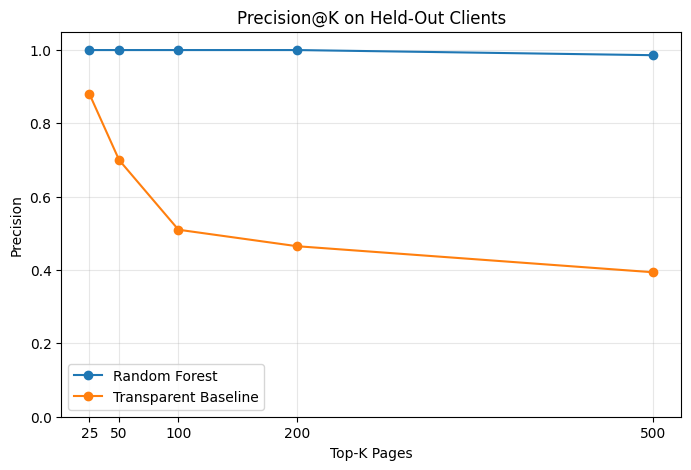

In [37]:
import matplotlib.pyplot as plt

k_values = [25, 50, 100, 200, 500]

rf_precision = [
    precision_at_k(test_results, "rf_score", k)
    for k in k_values
]

baseline_precision = [
    precision_at_k(test_results, "baseline_score", k)
    for k in k_values
]

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    rf_precision,
    marker="o",
    label="Random Forest"
)

plt.plot(
    k_values,
    baseline_precision,
    marker="o",
    label="Transparent Baseline"
)

plt.xlabel("Top-K Pages")
plt.ylabel("Precision")
plt.title("Precision@K on Held-Out Clients")
plt.xticks(k_values)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

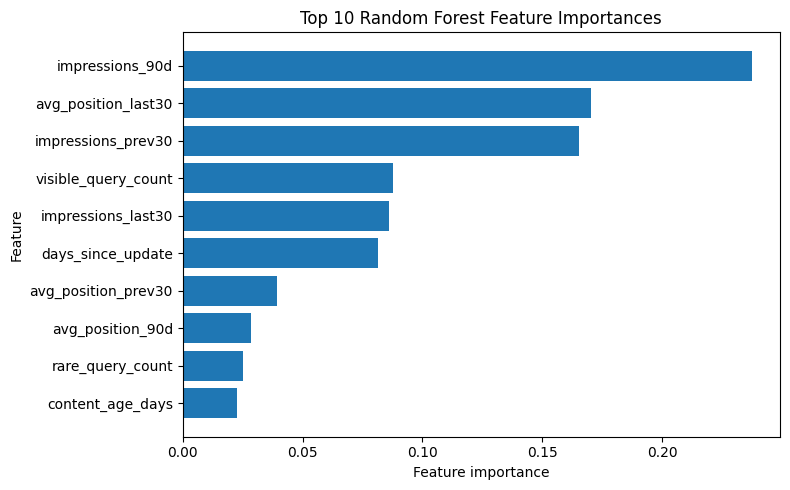

In [38]:
import matplotlib.pyplot as plt

top_features = (
    feature_importance
    .sort_values("importance", ascending=True)
    .tail(10)
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

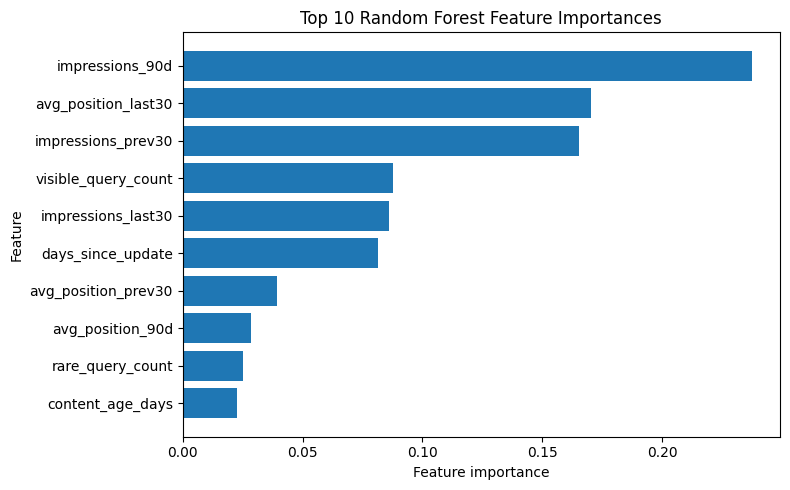

In [39]:
top_features = (
    feature_importance
    .sort_values("importance", ascending=True)
    .tail(10)
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

## 2. Data

This analysis uses the FlyRank internship warehouse release and focuses on the **Refresh / Content Opportunity Scoring** lane.

Two warehouse tables were used:

* `fact_content_query_90d`: 2,414,248 query-page observations containing impressions, clicks, CTR-related signals, and ranking-position information.
* `dim_content`: 519,606 content records containing content age, update history, content type, search demand, competition, backlinks, and content-size features.

The query-level data were aggregated to the page level using `client_hash_id` and `content_hash_id`. After joining the aggregated query data with the content table, the final analysis dataset contained **133,852 page-level records across 52 anonymized clients**.

The available search window covered **April 2, 2026 through June 30, 2026**.

No client names, domains, URLs, private search queries, credentials, or raw client exports are included in this analysis.

Because the released data provide a single fixed observation window, this study does not contain a future-period outcome. Therefore, the analysis evaluates **observed content-opportunity signals** rather than measuring whether a later refresh actually improved performance.

## 3. Methodology

### 3.1 Research Question

The analysis asks:

> **Which content pages should be prioritized for human review or potential refresh based on observable search-performance and content signals?**

The objective is decision support rather than prediction of Google's ranking algorithm or estimation of the causal effect of refreshing content.

### 3.2 Feature Engineering

Page-level signals were derived from the warehouse data, including:

* 90-day impressions and clicks
* Last-30-day and previous-30-day impressions and clicks
* Average ranking position
* Number of visible queries
* Rare-query signals
* Content age
* Days since content update
* Search volume
* Competition
* Backlinks
* Content length and structure

Additional directional signals were calculated from the change between the last 30 days and the previous 30 days.

A page was considered **stale** when it had not been updated for at least 90 days.

A page was considered to have **meaningful visibility** when it had at least 100 impressions during the 90-day period.

A page was considered **declining** when its impressions decreased by at least 20% between the previous and latest 30-day periods.

A page was considered to have **ranking deterioration** when its average position worsened by at least 5 positions.

A low-CTR opportunity was identified among pages with at least 100 impressions and non-zero clicks using the 25th percentile of observed CTR. This threshold was approximately **0.001263**.

### 3.3 Observed Opportunity Label

An `refresh_opportunity` label was constructed from combinations of these observable signals.

A page was labeled as an opportunity when it satisfied at least one of the following:

1. Stale + meaningful visibility + impression decline
2. Meaningful visibility + impression decline + ranking deterioration
3. Stale + meaningful visibility + low CTR

This label represents a **defined observed opportunity condition**. It is not a ground-truth measure of whether refreshing the page would succeed.

The resulting dataset contained **20,593 opportunity pages (15.38%)**.

### 3.4 Transparent Baseline

A transparent scoring baseline was created to provide an interpretable ranking for comparison with the machine-learning model.

The baseline combined:

* 30% staleness
* 25% visibility
* 20% impression decline
* 15% ranking position
* 10% CTR opportunity

Each component was normalized or capped to reduce the influence of extreme observations.

The baseline provides an interpretable reference against which the learned ranking can be compared.

### 3.5 Machine-Learning Model

A Random Forest classifier was trained using 20 numeric features.

Model configuration:

* 300 trees
* Maximum depth: 10
* Minimum samples per leaf: 20
* Balanced class weighting
* Random state: 42

Missing numeric values were median-imputed. The imputer was fitted only on the training data and then applied to the held-out test data.

### 3.6 Evaluation Design

To reduce client-level leakage, the data were divided using a **client-grouped 80/20 split**.

* Training pages: 117,944
* Test pages: 15,908
* Training clients: 41
* Held-out clients: 11
* Client overlap: 0

The primary evaluation metric was **Precision@K**, measuring the proportion of observed opportunity pages among the top K pages ranked by each method.

Precision was evaluated at K = 25, 50, 100, 200, and 500.

A random-ranking reference was also reported using the opportunity rate of the held-out test set.


## 4. Results

The held-out test set contained an observed opportunity rate of approximately **13.0%**, which serves as the random-ranking reference.

The Random Forest concentrated observed opportunity pages strongly near the top of its ranking.

| Top-K | Random Reference | Transparent Baseline | Random Forest |
| ----: | ---------------: | -------------------: | ------------: |
|    25 |            0.130 |                0.880 |         1.000 |
|    50 |            0.130 |                0.700 |         1.000 |
|   100 |            0.130 |                0.510 |         1.000 |
|   200 |            0.130 |                0.465 |         1.000 |
|   500 |            0.130 |                0.394 |         0.986 |

At the top 50 positions, the Random Forest identified **50 of 50 pages** that matched the observed opportunity definition, compared with **35 of 50** for the transparent baseline.

On the held-out client set, the model therefore produced substantially stronger concentration of the **defined opportunity label** than both the random reference and the transparent baseline.

However, these results should not be interpreted as 100% prediction accuracy or evidence that refreshing these pages will improve rankings. The target itself was constructed from observable performance and content signals that were also available to the model. Therefore, the strong Precision@K values demonstrate that the model effectively recovers and prioritizes the defined opportunity pattern, rather than independently proving the success of future content refreshes.

### 4.1 Feature Importance

The Random Forest assigned the highest feature importance to:

1. `impressions_90d` — 0.237
2. `avg_position_last30` — 0.170
3. `impressions_prev30` — 0.165
4. `visible_query_count` — 0.088
5. `impressions_last30` — 0.086
6. `days_since_update` — 0.081

This indicates that visibility, recent ranking position, historical visibility, and content-update recency were the strongest contributors to the model's observed opportunity classification.

## 5. Limitations and Honest Framing

Several limitations affect how these results should be interpreted.

First, the available warehouse data contain one fixed observation window rather than a before-and-after refresh experiment. The analysis therefore cannot determine whether a future content refresh would improve impressions, clicks, CTR, or ranking position.

Second, the opportunity label is constructed from observable rules. Because several of the same signals used to construct the label are also used as model features, the high model Precision@K partly reflects the model's ability to recover the predefined opportunity pattern.

Third, the client-grouped split prevents pages from the same client appearing in both training and testing sets, which provides a stronger generalization check. However, only 11 clients were held out, so performance may differ on a larger or different client population.

Fourth, search-performance signals alone do not capture editorial quality, business priorities, conversion value, brand considerations, topical authority, or human judgment.

Finally, the ranking should be treated as a **decision-support system for prioritizing human review**, not as an automated instruction that every high-scoring page should be refreshed.

No causal claims are made about Google's ranking system or about the effect of content refreshes.


## 6. Ranked Recommendations

The final system produces a ranked list of anonymized content pages using the Random Forest opportunity score.

The ranking is intended to help a content team decide **which pages deserve human review first**.

The recommended interpretation of the ranking is:

| Priority | Recommended action     | Typical supporting signals                                               |
| -------- | ---------------------- | ------------------------------------------------------------------------ |
| High     | Refresh / review       | Strong decline, stale content, worsening position, meaningful visibility |
| Medium   | Review CTR opportunity | Meaningful visibility with relatively weak CTR                           |
| Medium   | Review for refresh     | Staleness combined with weaker performance signals                       |
| Low      | Monitor                | Limited evidence of an immediate opportunity                             |

The top-ranked pages in the held-out set showed combinations of substantial impression decline, older update dates, and ranking deterioration. For example, several high-priority pages showed impression declines greater than 90% while also exhibiting other opportunity signals.

The ranking therefore provides a practical prioritization mechanism: **pages with stronger combinations of observable opportunity signals appear earlier in the review queue**.

Human review remains necessary before taking action because the model does not observe all editorial or business context.

## 7. Reproducibility

The analysis can be reproduced using the FlyRank internship warehouse release and the notebook workflow provided with this submission.

The main reproducibility settings are:

* Page-level aggregation by `client_hash_id` and `content_hash_id`
* Observation window: April 2, 2026 – June 30, 2026
* Client-grouped 80/20 train-test split
* Random state: 42
* Median imputation fitted on training data
* Random Forest with 300 trees, maximum depth 10, and minimum leaf size 20
* Precision@K evaluation at 25, 50, 100, 200, and 500
* No client names, URLs, private queries, credentials, or raw exports included in the public analysis

The warehouse access token is used only for authenticated dataset access and is not included in the notebook or submission.

## 8. Acknowledgments and Data Credit

This analysis was completed using the FlyRank internship warehouse release provided for the ML Capstone.

The analysis uses anonymized warehouse data for research and educational purposes. No client-identifying information or private search data are disclosed in the public submission.


In [40]:
# ==========================================
# FINAL REPRODUCIBILITY SUMMARY
# ==========================================

print("FINAL CAPSTONE RESULTS")
print("=" * 50)

print(f"Total page-level records: {len(df):,}")
print(f"Clients: {df['client_hash_id'].nunique()}")
print(f"Observed opportunity pages: {df['refresh_opportunity'].sum():,}")
print(f"Opportunity rate: {df['refresh_opportunity'].mean():.3%}")

print("\nTRAIN / TEST SPLIT")
print("-" * 50)
print(f"Training pages: {len(train_df):,}")
print(f"Test pages: {len(test_df):,}")
print(f"Training clients: {train_df['client_hash_id'].nunique()}")
print(f"Test clients: {test_df['client_hash_id'].nunique()}")

print("\nPRECISION@K")
print("-" * 50)

for k in [25, 50, 100, 200, 500]:
    rf_p = precision_at_k(test_results, "rf_score", k)
    baseline_p = precision_at_k(test_results, "baseline_score", k)

    print(
        f"Precision@{k}: "
        f"RF = {rf_p:.3f}, "
        f"Baseline = {baseline_p:.3f}"
    )

print("\nTOP 20 RECOMMENDATIONS")
print("-" * 50)

display(final_recommendations)

FINAL CAPSTONE RESULTS
Total page-level records: 133,852
Clients: 52
Observed opportunity pages: 20,593
Opportunity rate: 15.385%

TRAIN / TEST SPLIT
--------------------------------------------------
Training pages: 117,944
Test pages: 15,908
Training clients: 41
Test clients: 11

PRECISION@K
--------------------------------------------------
Precision@25: RF = 1.000, Baseline = 0.880
Precision@50: RF = 1.000, Baseline = 0.700
Precision@100: RF = 1.000, Baseline = 0.510
Precision@200: RF = 1.000, Baseline = 0.465
Precision@500: RF = 0.986, Baseline = 0.394

TOP 20 RECOMMENDATIONS
--------------------------------------------------


,rank,content_hash_id,priority_score,reason_code,recommended_action,impression_change,days_since_update
44522,1,content_73ccf724287af473,0.944,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-62.9%,125
44978,2,content_f146d3ce3ad5cea2,0.943,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-58.3%,125
44473,3,content_65c8535db37e210e,0.942,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-97.0%,113
44707,4,content_a54312bc51d8c4b3,0.939,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-82.5%,125
44681,5,content_9e259e1791fd8a4e,0.934,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-95.8%,125
44347,6,content_4700bed3f94c9f12,0.934,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-73.1%,125
44971,7,content_ee16e194c98cebea,0.927,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-91.0%,125
68735,8,content_c6f503832efa4a8f,0.922,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-86.4%,125
130185,9,content_9902cb123fcf0dc9,0.922,DECLINING + RANKING_WORSENED + MEANINGFUL_VISI...,Refresh / review,-99.5%,2
44250,10,content_302a85ddefb8097d,0.922,STALE + DECLINING + RANKING_WORSENED + MEANING...,Refresh / review,-75.5%,125


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.